### ***** Description : ***** 

Ici je créé un script qui va identifier les RBD et créer une colonne debut et fin de RBD en seconde dans mon fichier excel

In [3]:
import re
import math
import numpy as np
import pandas as pd

excel_file = "../data/BDD_RBD_patients.xlsx"
sheet_name = "classification"
df = pd.read_excel(excel_file, sheet_name=sheet_name)

# Afficher les premières lignes d'un DataFrame
df.head()



,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,mouvements,Unnamed: 9,...,Unnamed: 51,Unnamed: 52,manifestations émotionnelles,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,manifestations végétatives,Unnamed: 59,Unnamed: 60
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,type,NaN,...,NaN,NaN,grimace,NaN,NaN,rire,pleurs,modifications respiratoires,sueurs (dermogramme),tachycardie
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evenements élémentaires myocloniques (secousse...,NaN,...,ton autoritaire,soupire/souffle,positive (sourire),negative (fronce sourcil),indeterminée,NaN,NaN,NaN,NaN,NaN
2,NaN,identifiant,Diagnostic,type de mouvements,Durée TCSP,event respiratoire,Nombre d'épisodes RDB,Valence émotionnelle,simples,Majeurs (saccade de l'ensemble du corps),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,X,IB1,PARK,video 1: parle en Arabe ...,1min,apnée obstructive pendant le TCSP,2,negative,0,0,...,0,0,0,1,0,0,0,NaN,NaN,NaN
4,NaN,NaN,NaN,"vidéo 2: rigole x2 et dit ""euh eh""",27s,NaN,NaN,positive,0,0,...,0,0,1,0,0,1,0,NaN,NaN,NaN


In [ ]:
import os
import re
from openpyxl import load_workbook

# === Paramètres ===
INPUT_XLSX  = "../data/BDD_RBD_patients.xlsx"
OUTPUT_XLSX = INPUT_XLSX.replace(".xlsx", "") + "_updated.xlsx"
SHEET_NAME  = "classification"

ROW_START = 5  # on commence les données à la ligne 5 

# En-têtes (ligne 4 seulement)
HDR_STUDIED = "Étudié avec Darryl (oui/non)"
HDR_F = "extrait/entier"
HDR_G = "debut_RBD(s)"
HDR_H = "fin_RBD(s)"

# Dossier de référence pour marquer "oui"/"non"
FOLDER_ROOT = "../../documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/"

# === Utilitaires ===
def _to_str(x):
    return "" if x is None else str(x)

def parse_time_like_to_seconds(text):
    """
    Extrait et convertit en secondes la première mention de temps trouvée dans `text`.
    Gère : hh:mm:ss, mm:ss, h/min/s (fr), 'après 15 min', etc. Retourne None si rien.
    """
    if text is None:
        return None
    s = _to_str(text).lower().strip()

    # 1) hh:mm[:ss] ou mm:ss
    m = re.search(r'(\d{1,2}):(\d{1,2})(?::(\d{1,2}))?', s)
    if m:
        g1 = int(m.group(1)); g2 = int(m.group(2)); g3 = int(m.group(3)) if m.group(3) else 0
        return g1*3600 + g2*60 + g3 if m.group(3) is not None else g1*60 + g2

    # 2) unités FR (h/min/s)
    h = mn = sec = None
    mh = re.search(r'(\d+)\s*h(?:eures?)?', s)
    if mh: h = int(mh.group(1))
    mmn = re.search(r'(\d+)\s*(?:min|m)(?![a-z])', s)
    if mmn: mn = int(mmn.group(1))
    ms = re.search(r'(\d+)\s*s(?:ec(?:ondes?)?)?', s)
    if ms: sec = int(ms.group(1))
    if h is not None or mn is not None or sec is not None:
        return (h or 0)*3600 + (mn or 0)*60 + (sec or 0)

    # 3) 'après X ...'
    mapres = re.search(r"apr[eè]s\s+(\d+)\s*(h|heures?|min|m|s|sec(?:ondes?)?)", s)
    if mapres:
        qty = int(mapres.group(1)); unit = mapres.group(2)
        if unit.startswith('h') or unit.startswith('heur'): return qty * 3600
        if unit in ('min', 'm'): return qty * 60
        return qty

    # 4) nombre brut (secondes) si raisonnable (<= 24h)
    try:
        val = float(s.replace(',', '.'))
        if 0 <= val <= 24*3600:
            return val
    except Exception:
        pass
    return None

def contains_video_flag(text):
    return re.search(r'vid[eé]o', _to_str(text).lower()) is not None

# === Prépare la liste des IDs disponibles (noms de dossiers) ===
existing_ids = set()
if os.path.isdir(FOLDER_ROOT):
    for name in os.listdir(FOLDER_ROOT):
        full = os.path.join(FOLDER_ROOT, name)
        if os.path.isdir(full):
            existing_ids.add(str(name).strip())
else:
    print(f">>> Dossier introuvable : {FOLDER_ROOT} - les lignes avec identifiant seront marquées 'non'.")

# === Ouvrir et modifier la feuille ===
wb = load_workbook(INPUT_XLSX)
ws = wb[SHEET_NAME] if SHEET_NAME else wb.active
max_row = ws.max_row

# --- 1) Insérer la colonne "Étudié..." AVANT la colonne Identifiant (on suppose Identifiant initialement en B) ---
# Pour être robuste, on cherche la colonne 'Identifiant' en ligne 4 ; sinon on assume B (col=2).
ident_col_idx = 2
for c in range(1, ws.max_column + 1):
    if _to_str(ws.cell(row=4, column=c).value).strip().lower() == "identifiant":
        ident_col_idx = c
        break

# Si l'en-tête HDR_STUDIED n'est pas déjà juste avant 'Identifiant', on insère 1 colonne à ident_col_idx
if _to_str(ws.cell(row=4, column=ident_col_idx - 1).value).strip().lower() != HDR_STUDIED.lower():
    ws.insert_cols(ident_col_idx)
    # après insertion, Identifiant est décalé d'1 vers la droite, et la nouvelle colonne est à ident_col_idx
else:
    # La colonne existe déjà ; on ne réinsère pas.
    pass

# Écrire l’en-tête en ligne 4 uniquement (ne rien toucher en 1-3)
studied_col_idx = ident_col_idx  # position de la colonne insérée
ws.cell(row=4, column=studied_col_idx, value=HDR_STUDIED)

# L'identifiant est maintenant en (ident_col_idx + 1)
ident_data_col = ident_col_idx + 1

# Remplir la colonne "Étudié..." à partir de la ligne 5 ; si ID vide -> SKIP (laisse vide)
for r in range(ROW_START, max_row + 1):
    id_val = _to_str(ws.cell(row=r, column=ident_data_col).value).strip()
    if id_val == "":
        studied = None  # skip si identifiant vide
    else:
        studied = "oui" if id_val in existing_ids else "non"
    ws.cell(row=r, column=studied_col_idx, value=studied)

# --- 2) Ajouter/mettre à jour les colonnes F-H (extrait/début/fin) en préservant fusions ---
# Après l'insertion d'une colonne avant Identifiant, les index colonnes d'origine sont décalés.
# Si, à l'origine, D=4 et E=5, et qu'on a inséré une colonne avant B (col=2) ou juste avant 'Identifiant',
# alors D -> D+1 et E -> E+1. On fixe D_idx et E_idx *après* notre insertion.
D_idx = 5  # D original + 1
E_idx = 6  # E original + 1

# On veut insérer 3 colonnes juste après E => à partir de (E_idx + 1)
insert_after_E_idx = E_idx + 1  # première nouvelle colonne (ex-HDR_F)

# Si les en-têtes attendus ne sont pas déjà posés en ligne 4, on insère 3 colonnes
already_ok = (
    _to_str(ws.cell(row=4, column=insert_after_E_idx).value).strip().lower() == HDR_F.lower() and
    _to_str(ws.cell(row=4, column=insert_after_E_idx+1).value).strip().lower() == HDR_G.lower() and
    _to_str(ws.cell(row=4, column=insert_after_E_idx+2).value).strip().lower() == HDR_H.lower()
)
if not already_ok:
    ws.insert_cols(insert_after_E_idx, amount=3)

# Écrire les en-têtes en ligne 4 (ne rien écrire en 1-3)
ws.cell(row=4, column=insert_after_E_idx,     value=HDR_F)
ws.cell(row=4, column=insert_after_E_idx + 1, value=HDR_G)
ws.cell(row=4, column=insert_after_E_idx + 2, value=HDR_H)

# Remplir valeurs à partir de ROW_START, en propageant le label extrait/entier quand Identifiant est vide
last_label_for_patient = None
for r in range(ROW_START, max_row + 1):
    colD = ws.cell(row=r, column=D_idx).value
    colE = ws.cell(row=r, column=E_idx).value
    id_val = _to_str(ws.cell(row=r, column=ident_data_col).value).strip()

    if id_val != "":
        last_label_for_patient = "extrait" if contains_video_flag(colD) else "entier"
        label = last_label_for_patient
    else:
        label = last_label_for_patient if last_label_for_patient is not None else ("extrait" if contains_video_flag(colD) else "entier")

    debut_s = parse_time_like_to_seconds(colD)
    duree_s = parse_time_like_to_seconds(colE)
    fin_s   = (debut_s + duree_s) if (debut_s is not None and duree_s is not None) else None

    ws.cell(row=r, column=insert_after_E_idx,     value=label)
    ws.cell(row=r, column=insert_after_E_idx + 1, value=debut_s)
    ws.cell(row=r, column=insert_after_E_idx + 2, value=fin_s)

# --- Sauvegarde ---
wb.save(OUTPUT_XLSX)
print(f">>> Terminé. Fichier écrit : {OUTPUT_XLSX}")


>>> Terminé. Fichier écrit : ../data/BDD_RBD_patients_updated.xlsx


## ***** Analysons l'amplitude de mes signaux EMG sur ces fenêtres *****

## 1 - Visu

Opening raw data file /home/darryld/documents/EEG/preprocessed/bipolaire/2_rem_only/gp2/BB114/BB114_annotated_150.fif...
    Range : 0 ... 7678719 =      0.000 ... 29994.996 secs
Ready.


/tmp/ipykernel_3549365/561131413.py:7: RuntimeWarning: This filename (/home/darryld/documents/EEG/preprocessed/bipolaire/2_rem_only/gp2/BB114/BB114_annotated_150.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(file_path, preload=True)


Reading 0 ... 7678719  =      0.000 ... 29994.996 secs...


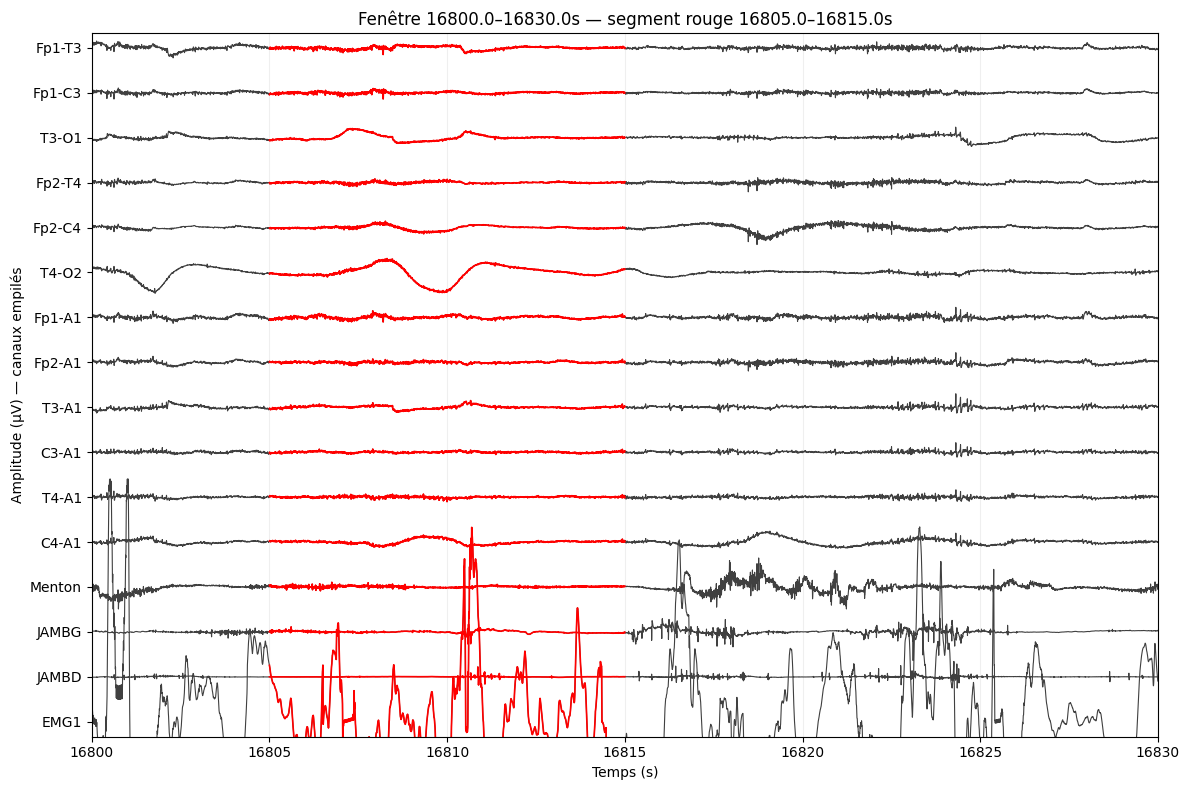

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# --- Chemins & chargement ---
file_path = "/home/darryld/documents/EEG/preprocessed/bipolaire/2_rem_only/gp2/BB114/BB114_annotated_150.fif"
raw = mne.io.read_raw_fif(file_path, preload=True)

# --- Paramètres d'affichage ---
page_sec = 30.0             # durée de la "page" affichée (style polysomnographie)
page_start = 16800.0        # début de la page (en s, à adapter)
highlight_dur = 10.0        # durée de la portion à colorer en rouge (s)
highlight_start = page_start + 5.0  # début de la portion rouge à l'intérieur de la page

picks = mne.pick_types(raw.info, eeg=True, eog=True, emg=True)  # adapte (eeg/eog/emg)
max_channels = 16            # nombre de canaux à afficher
picks = picks[:max_channels]

# --- Extraction des données de la page ---
sfreq = raw.info['sfreq']
i0 = int((page_start - raw.first_time) * sfreq)
i1 = int(((page_start + page_sec) - raw.first_time) * sfreq)
i0 = max(i0, 0); i1 = min(i1, raw.n_times)

data, times = raw.get_data(picks=picks, start=i0, stop=i1, return_times=True)

# --- Mise à l'échelle (en µV) et centrage par canal pour une belle pile ---
data = data * 1e6  # V -> µV
data = data - np.median(data, axis=1, keepdims=True)

# --- Décimation légère pour l'affichage (facultatif) ---
target_pts = 6000
decim = max(1, data.shape[1] // target_pts)
data = data[:, ::decim]
times = times[::decim]

# --- Masque temporel pour le segment rouge ---
mask = (times >= highlight_start) & (times <= (highlight_start + highlight_dur))

# --- Construction de la pile avec espacement ---
spacing = np.nanpercentile(np.abs(data), 95)  # espacement empirique
offsets = np.arange(len(picks))[::-1] * (spacing * 3.0)  # 3x pour éviter le chevauchement
data_stack = data + offsets[:, None]

# --- Tracé ---
fig, ax = plt.subplots(figsize=(12, 8))

# Traces grises (toute la page)
for ch_idx in range(len(picks)):
    ax.plot(times, data_stack[ch_idx], lw=0.8, color='0.25')

# Portion rouge (même signal mais uniquement sur le masque)
for ch_idx in range(len(picks)):
    y = data_stack[ch_idx].copy()
    y[~mask] = np.nan  # NaN -> segments interrompus hors fenêtre
    ax.plot(times, y, lw=1.2, color='red')

# Cosmétiques
ax.set_xlim(page_start, page_start + page_sec)
ax.set_ylim(offsets[-1] - spacing, offsets[0] + spacing)
ax.set_xlabel("Temps (s)")
ax.set_ylabel("Amplitude (µV) - canaux empilés")
ax.set_title(f"Fenêtre {page_start:.1f}-{page_start+page_sec:.1f}s - segment rouge {highlight_start:.1f}-{(highlight_start+highlight_dur):.1f}s")

# Étiquettes des canaux sur l'axe Y
ax.set_yticks(offsets)
ax.set_yticklabels([raw.ch_names[p] for p in picks])

# Optionnel : bandeau de fond pour repérer visuellement la zone rouge
#ax.axvspan(highlight_start, highlight_start + highlight_dur, alpha=0.12, color='red', zorder=0)

ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()


## 2 - Détection RBD manuelle

#### 2.1 - Dictionnaire pour chaque patient avec les fenêtres RBD identifiées visuellement

In [1]:
import os
import pandas as pd
from collections import defaultdict

# ----- Paramètres -----
EXCEL_PATH = "../data/BDD_RBD_patients_updated.xlsx"
SHEET_NAME = "classification"
HEADER_ROW = 3   # ligne 4 dans Excel

# Noms de colonnes attendues (tels qu’en ligne 4)
COL_ID      = "identifiant"
COL_STUDIED = "Étudié avec Darryl (oui/non)"
COL_DEBUT   = "debut_RBD(s)"
COL_FIN     = "fin_RBD(s)"
COL_LABEL   = "extrait/entier"
COL_DESC    = "type de mouvements "

# Répertoire des patients étudiés (dossiers gp2)
GP2_DIR = "../../documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/"

# ----- Lecture -----
df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME, header=HEADER_ROW)

# Vérifs minimales
for c in [COL_ID, COL_STUDIED, COL_DEBUT, COL_FIN]:
    if c not in df.columns:
        raise ValueError(f"Colonne manquante dans l'Excel: {c!r}")

# ----- Liste "stricte" des patients depuis gp2 (exact match, sensible à la casse) -----
if not os.path.isdir(GP2_DIR):
    raise FileNotFoundError(f"Répertoire introuvable: {GP2_DIR}")

patients_gp2 = {name.strip() for name in os.listdir(GP2_DIR) if os.path.isdir(os.path.join(GP2_DIR, name))}
print(f"Dossiers patients trouvés sur le Serveur: {len(patients_gp2)}")

# ----- Préparation des données Excel -----
# On propage l'ID et 'Étudié...' pour capturer les lignes de continuation (ID vide)
df["__id_ffill"] = df[COL_ID].ffill()
df["__studied_ffill"] = df[COL_STUDIED].ffill()

# Normalisations utiles
df["__id_ffill"] = df["__id_ffill"].astype(str).str.strip()
df["__studied_ffill_norm"] = df["__studied_ffill"].astype(str).str.strip().str.lower()

# Filtre: patients étudiés = 'oui' (après propagation)
mask_studied = df["__studied_ffill_norm"].eq("oui")
mask_times   = df[COL_DEBUT].notna() & df[COL_FIN].notna()

# On garde seulement les lignes avec temps renseignés et étudié=oui
sub = df.loc[mask_studied & mask_times].copy()

# Conversion sûre en float (secondes)
sub[COL_DEBUT] = pd.to_numeric(sub[COL_DEBUT], errors="coerce")
sub[COL_FIN]   = pd.to_numeric(sub[COL_FIN], errors="coerce")
sub = sub.loc[sub[COL_DEBUT].notna() & sub[COL_FIN].notna() & (sub[COL_FIN] > sub[COL_DEBUT])].copy()

# ----- Sélection stricte: l'ID doit correspondre à un dossier présent dans gp2 -----
# (Comparaison stricte: sensible à la casse ; on enlève juste les espaces de bord)
sub["__id_ffill"] = sub["__id_ffill"].astype(str).str.strip()
sub = sub[sub["__id_ffill"].isin(patients_gp2)].copy()

# ----- Construction du dictionnaire -----
windows_by_patient = defaultdict(list)

for _, row in sub.iterrows():
    pid = row["__id_ffill"]

    # Description nettoyée (retire ":" et tokens purement numériques)
    desc = row[COL_DESC] if (COL_DESC in sub.columns) else None
    if isinstance(desc, str):
        desc = desc.replace(":", "").strip()
        desc = " ".join(tok for tok in desc.split() if not tok.isdigit())

    label = row[COL_LABEL] if (COL_LABEL in sub.columns) else None

    windows_by_patient[pid].append({
        "start": float(row[COL_DEBUT]),
        "end": float(row[COL_FIN]),
        "duration(s)": float(row[COL_FIN] - row[COL_DEBUT]),
        "description": desc,
        "extrait/entier": label,
    })

# Tri des fenêtres par début
for pid in list(windows_by_patient.keys()):
    windows_by_patient[pid].sort(key=lambda d: d["start"])

# ----- Diagnostics -----
# Patients marqués "oui" (après ffill) présents dans le classeur
ids_yes_in_excel = set(df.loc[df["__studied_ffill_norm"].eq("oui"), "__id_ffill"].astype(str).str.strip().unique())
ids_yes_in_excel.discard("")  # au cas où

# Intersection stricte avec gp2
ids_yes_and_in_gp2 = sorted(id_ for id_ in ids_yes_in_excel if id_ in patients_gp2)
ids_final = sorted(windows_by_patient.keys())

print(f"\nPatients 'oui' détectés dans l'Excel: {len(ids_yes_in_excel)}")
print(f"Patients 'oui' qui existent sur le serveur: {len(ids_yes_and_in_gp2)}")
print(f"Total de fenêtres RBD collectées: {sum(len(v) for v in windows_by_patient.values())}")

# Patients 'oui' présents dans gp2 mais sans fenêtre valide
missing_windows = sorted(set(ids_yes_and_in_gp2) - set(ids_final))
if missing_windows:
    print("\nPatients 'oui' présents sur le serveur mais SANS fenêtre valide:")
    for pid in missing_windows[:50]:
        print("  -", pid)
    if len(missing_windows) > 50:
        print(f"  ... (+{len(missing_windows)-50} autres)")

# Exemples d'aperçu
if ids_final[:5]:
    print("\nExemples (jusqu'à 5 IDs):", ids_final[:5])
    for pid in ids_final[:3]:
        print(f"\nPatient {pid}:")
        for win in windows_by_patient[pid][:100]:
            print("  -", win)

# L'objet utile : windows_by_patient
# ex: windows_by_patient['AN166'][:2]


Dossiers patients trouvés sur le Serveur: 76

Patients 'oui' détectés dans l'Excel: 69
Patients 'oui' qui existent sur le serveur: 58
Total de fenêtres RBD collectées: 453

Patients 'oui' présents sur le serveur mais SANS fenêtre valide:
  - BDRE44
  - GX111
  - LF126
  - LJ41
  - MN26
  - RJ42

Exemples (jusqu'à 5 IDs): ['AE129', 'BA152', 'BA171', 'BB114', 'BF181']

Patient AE129:
  - {'start': 4323.0, 'end': 4350.0, 'duration(s)': 27.0, 'description': 'mvt de la tête, bruit bizarre de la bouche en levant la main gauche', 'extrait/entier': 'entier'}
  - {'start': 4833.0, 'end': 4862.0, 'duration(s)': 29.0, 'description': 'mvt très restreints myocloniques répétés des mains et des jambes. Souffle à', 'extrait/entier': 'entier'}
  - {'start': 5888.0, 'end': 5904.0, 'duration(s)': 16.0, 'description': 'lève la tête , bouge la main gauche (doigts) et les jambes', 'extrait/entier': 'entier'}

Patient BA152:
  - {'start': 6526.0, 'end': 6620.0, 'duration(s)': 94.0, 'description': 'gémit et m

#### 2.2 - Mise en évidence des RBD identifiés manuellement

Patient: EF130 | Fenêtres RBD: 2 | REM: 8 (époque=30s)


/tmp/ipykernel_3783119/3549112084.py:123: RuntimeWarning: This filename (/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_art_annotated.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


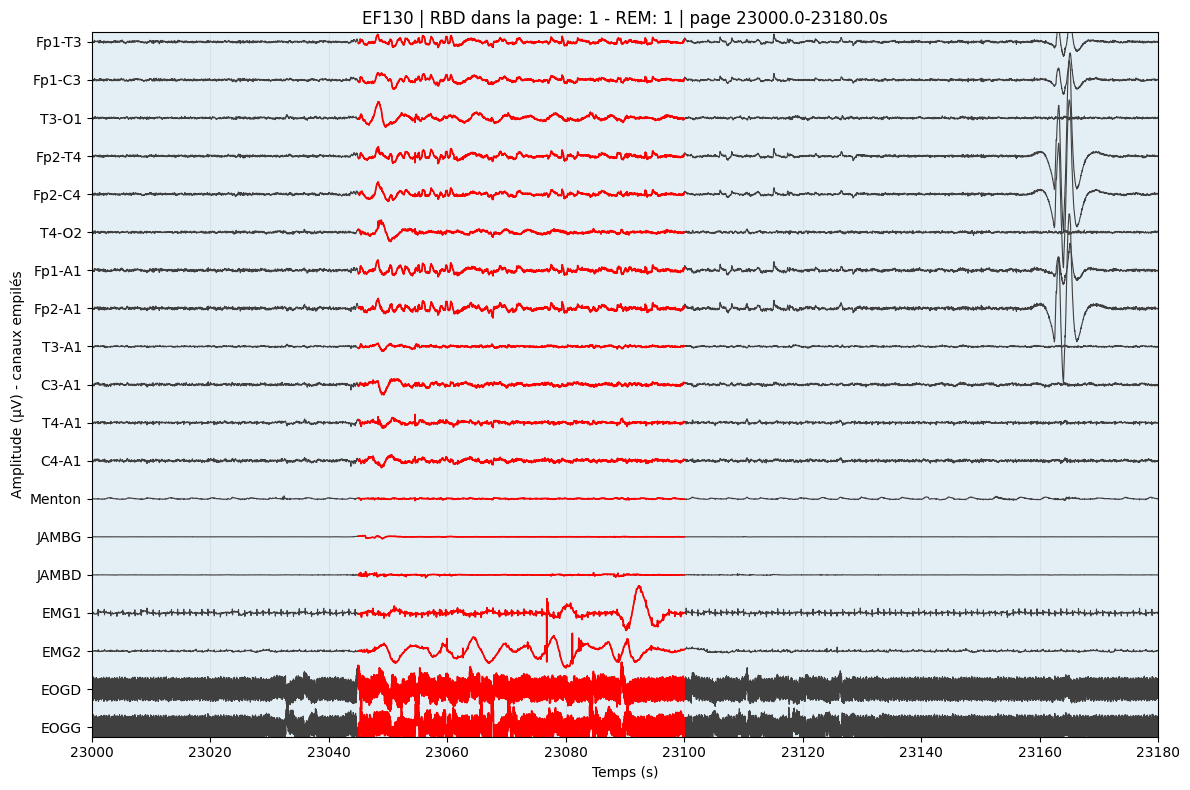

In [ ]:
# === À coller dans une cellule ===
import os
from pathlib import Path
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# ========= Paramètres =========
hypno_path = "/home/darryld/documents/EEG/raw/EF130/EF130_hypnoEXP.txt"   
fif_file   = "/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_art_annotated.fif"

SHOW_REM_SHADE = True        
HYPNO_OFFSET_S = 0.0         # décalage des REM si besoin

# Affichage "page"
page_sec   = 180.0
page_start = 23000.0          
max_channels = 20
DECIM_TARGET_PTS = 6000
PICK_EEG, PICK_EOG, PICK_EMG = True, True, True

# GAIN VISUEL des canaux EMG (insensible à la casse, match par inclusion)
# Exemple: 0.5 pour diviser par 2, 2.0 pour doubler l’amplitude
EMG_GAINS = {"EMG1": 2.0, "EMG2": 2.0}

# ========= Utilitaires =========
def extract_patient_id_from_path(fpath: str) -> str:
    p = Path(fpath).resolve()
    parts = list(p.parts)
    for i, seg in enumerate(parts):
        if seg.lower() == "gp2" and i + 1 < len(parts):
            return parts[i + 1]
    return p.parent.name  # fallback

def build_union_mask(times: np.ndarray, intervals):
    mask = np.zeros_like(times, dtype=bool)
    for (a, b) in intervals:
        if b > a:
            mask |= (times >= a) & (times < b)
    return mask

def read_hypnogram_intervals_rem(path):
    """
    Lit un hypnogramme texte avec colonnes:
        0: temps cumulé en secondes (fin d'époque)
        1: HH:MM:SS (ignoré)
        2: stade: 'W','N1','N2','N3','R','REM', etc.
        3: optionnelle (ignorée)
    Retourne:
        - rem_intervals: liste de (start_s, end_s)
        - epoch_len: longueur d'époque détectée (en s)
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Hypnogramme introuvable: {path}")

    df = pd.read_csv(
        path,
        sep=r"\s+",
        engine="python",
        header=None,
        comment="#",
        names=["t_end_s", "hhmmss", "stage", "extra"],
        usecols=[0, 1, 2],           # on ignore la 4e si présente
        dtype={0: float, 1: str, 2: str},
        encoding_errors="ignore"
    )

    df = df.dropna(subset=["t_end_s", "stage"]).copy()
    df["stage"] = df["stage"].astype(str).str.strip().str.upper()

    # Détection de la durée d'époque (modale)
    diffs = np.diff(df["t_end_s"].to_numpy())
    if diffs.size == 0:
        epoch_len = 30.0
    else:
        epoch_len = float(pd.Series(np.round(diffs, 1)).mode().iloc[0])

    # Construction des intervalles REM (fusion des époques contiguës)
    is_rem = df["stage"].isin(["R", "REM"])
    rem_intervals = []
    run_start = None
    prev_end = None

    for t_end, flag in zip(df["t_end_s"], is_rem):
        t_start = t_end - epoch_len
        if flag:
            if run_start is None:
                run_start = t_start
            prev_end = t_end
        else:
            if run_start is not None:
                rem_intervals.append((float(run_start), float(prev_end)))
                run_start, prev_end = None, None

    if run_start is not None and prev_end is not None:
        rem_intervals.append((float(run_start), float(prev_end)))

    return rem_intervals, epoch_len


# ========= 1) Récup fenêtres RBD depuis windows_by_patient =========
if 'windows_by_patient' not in globals():
    raise RuntimeError("Le dict 'windows_by_patient' est introuvable. Exécute d'abord la cellule qui le construit.")

patient_id = extract_patient_id_from_path(fif_file)
wins = windows_by_patient.get(patient_id, [])
if not wins:
    print(f" Aucune fenêtre RBD pour {patient_id} dans 'windows_by_patient'.")

# Intervalles RBD (start, end) pour masquage rouge
rbd_intervals = [(float(w['start']), float(w['end'])) for w in wins if ('start' in w and 'end' in w)]

# ========= 2) (Optionnel) Intervalles REM pour ombrage de fond =========
rem_intervals, epoch_len = [], 30.0
if SHOW_REM_SHADE and hypno_path and os.path.isfile(hypno_path):
    rem_intervals, epoch_len = read_hypnogram_intervals_rem(hypno_path)
    if HYPNO_OFFSET_S:
        rem_intervals = [(a + HYPNO_OFFSET_S, b + HYPNO_OFFSET_S) for (a, b) in rem_intervals]
print(f"Patient: {patient_id} | Fenêtres RBD: {len(rbd_intervals)} | REM: {len(rem_intervals)} (époque={epoch_len:.0f}s)")

# ========= 3) Charger le FIF =========
raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
sfreq = raw.info["sfreq"]

# ========= 4) Choix canaux & page =========
picks = mne.pick_types(raw.info, meg=False, eeg=PICK_EEG, eog=PICK_EOG, emg=PICK_EMG, stim=False, misc=False)
picks = picks[:max_channels]
if len(picks) == 0:
    raise RuntimeError("Aucun canal sélectionné (vérifie PICK_EEG/EOG/EMG).")

i0 = int((page_start - raw.first_time) * sfreq)
i1 = int(((page_start + page_sec) - raw.first_time) * sfreq)
i0 = max(i0, 0); i1 = min(i1, raw.n_times)

data, times = raw.get_data(picks=picks, start=i0, stop=i1, return_times=True)
data = data * 1e6
data = data - np.median(data, axis=1, keepdims=True)

decim = max(1, data.shape[1] // DECIM_TARGET_PTS)
if decim > 1:
    data = data[:, ::decim]
    times = times[::decim]

# Appliquer les gains visuels sur EMG1/EMG2 (après décimation, avant empilement)
if EMG_GAINS:
    ch_names = [raw.ch_names[p] for p in picks]
    scale = np.ones(len(picks), dtype=float)
    # match insensible à la casse et par inclusion du nom demandé
    for i, nm in enumerate(ch_names):
        low = nm.lower()
        for key, gain in EMG_GAINS.items():
            if key.lower() in low:
                scale[i] = float(gain)
                break
    data = data * scale[:, None]

# Intersections avec la page
page_a, page_b = page_start, page_start + page_sec
def clip_to_page(intervals):
    out = []
    for a, b in intervals:
        aa, bb = max(a, page_a), min(b, page_b)
        if bb > aa:
            out.append((aa, bb))
    return out

rbd_in_page = clip_to_page(rbd_intervals)
rem_in_page = clip_to_page(rem_intervals)

mask_rbd = build_union_mask(times, rbd_in_page)
mask_rem = build_union_mask(times, rem_in_page)

# ========= 5) Tracé (gris + RBD rouge + REM ombré) =========
# Espacement calculé sur l'ensemble (calcule sur EEG uniquement possible si besoin)
spacing = np.nanpercentile(np.abs(data), 95) if data.size else 1.0
spacing = spacing if spacing > 0 else 1.0
offsets = np.arange(len(picks))[::-1] * (spacing * 4.0)
data_stack = data + offsets[:, None]

fig, ax = plt.subplots(figsize=(12, 8))

# Ombre REM en fond (bleu clair)
for (aa, bb) in rem_in_page:
    ax.axvspan(aa, bb, alpha=0.12)

# Signaux en gris
for ch_idx in range(len(picks)):
    ax.plot(times, data_stack[ch_idx], lw=0.8, color='0.25')

# Segments RBD en ROUGE (depuis windows_by_patient)
if mask_rbd.any():
    for ch_idx in range(len(picks)):
        y = data_stack[ch_idx].copy()
        y[~mask_rbd] = np.nan
        ax.plot(times, y, lw=1.2, color='red')

# Axes & titres
ax.set_xlim(page_a, page_b)
ax.set_ylim(offsets[-1] - spacing, offsets[0] + spacing)
ax.set_xlabel("Temps (s)")
ax.set_ylabel("Amplitude (µV) - canaux empilés")
ax.set_title(f"{patient_id} | RBD dans la page: {len(rbd_in_page)} - REM: {len(rem_in_page)} | page {page_a:.1f}-{page_b:.1f}s")

ax.set_yticks(offsets)
ax.set_yticklabels([raw.ch_names[p] for p in picks])
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()


## 3- Méthode semi-automatique de quantification du RSWA
*(d’après Possti et al., NPJ Digital Medicine, 2024)*

La méthode semi-automatique de détection du **REM Sleep Without Atonia (RSWA)** repose sur l’analyse du signal **EMG mentonnier** pendant le sommeil paradoxal (REM).  
Elle vise à quantifier automatiquement l’activité musculaire anormale tout en s’appuyant sur un staging REM manuel.

---

### Étape 1 - Prétraitement du signal EMG

Le signal EMG du menton est filtré avec :
- un **passe-haut à 30 Hz** pour éliminer les composantes basses (mouvements, respiration),
- un **notch à 50 Hz** (Q = 30) pour supprimer le bruit secteur,
- un **passe-bas à 100 Hz** .

L’échantillonnage est ramené à **500 Hz**.  
L’analyse est limitée aux **époques identifiées comme REM** (30s).

---

### Étape 2 - Calcul du MAAV (Mean Absolute Amplitude Value)

Le signal filtré est découpé en fenêtres de **0,1 s** avec **50 % de recouvrement**.

Pour chaque fenêtre, on calcule :

$
\mathrm{MAAV} = \frac{1}{N}\sum_{i=1}^{N} \lvert x_i \rvert
$

où \(x_i\) est l’amplitude du signal EMG dans la fenêtre.

Le vecteur MAAV représente l’enveloppe moyenne du signal EMG.

Deux **tests de normalité de Shapiro–Wilk** sont effectués :
1. sur le signal EMG filtré,
2. sur le vecteur MAAV.

Si les deux statistiques dépassent les seuils (0.95 et 0.9), l’époque REM est considérée **sans activité EMG** et exclue.

---

### Étape 3 - Détection adaptative des segments actifs

Un **seuil adaptatif** est défini au **55ᵉ percentile du MAAV** de chaque époque REM.  
Les segments où le MAAV dépasse ce seuil sont considérés comme **potentiellement actifs**.

Pour chaque segment, les critères suivants sont évalués :

| Caractéristique         | Condition d’activation                    |
|--------------------------|------------------------------------------|
| Fréquence médiane        | < 115 Hz                                 |
| RMS                      | > 2 × seuil MAAV                         |
| Taux de passage par zéro | > 140                                    |
| Pics FFT                 | ≠ harmoniques du 50 Hz                   |

Les segments validés sur ces quatre critères sont retenus comme **bursts EMG réels**.

---

### Étape 4 - Calcul du RSWA Index (RSWAi)

Le **RSWAi** est calculé comme le rapport entre la durée totale des activations EMG détectées et la durée totale de sommeil REM :

\[
RSWAi = \frac{\text{Durée des segments actifs}}{\text{Durée totale du sommeil REM}}
\]

Un seuil de **6.269** (déterminé par analyse ROC) permet la classification :

- **RSWAi > 6.269** --> RBD probable  
- **RSWAi ≤ 6.269** --> absence de RBD

---

Cette méthode est dite *semi-automatique* dans l'article car la sélection des périodes REM reste **manuelle**, tandis que la détection et la quantification des activations EMG sont **automatisées**.


In [3]:
# Visu